In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Import the CSVs as dataframes

In [2]:
REPO_ROOT = Path.cwd().parent
PREPROCESSED_DIR = REPO_ROOT / "data" / "preprocessed"
BIOSIGNALS_DIR = PREPROCESSED_DIR / "biosignals"
RESPONSES_DIR = PREPROCESSED_DIR / "responses"

PERSON1_BIOSIGNALS_CSV = BIOSIGNALS_DIR / "Person1_D1_1_ID_1.csv"
PERSON1_RESPONSES_CSV = RESPONSES_DIR / "Person1_D1_1_ID_1_responses.csv"

p1_biosigs_df = pd.read_csv(PERSON1_BIOSIGNALS_CSV)
p1_respons_df = pd.read_csv(PERSON1_RESPONSES_CSV)
p1_biosigs_df.head()

,time,BVP,EDA,HR,TEMP,round,phase
0,2021-12-17 16:11:55.000000,-12.3100,0.185827,76.75,30.97,round_1,phase1
1,2021-12-17 16:11:55.062500,26.7025,0.190312,76.75,30.97,round_1,phase1
2,2021-12-17 16:11:55.125000,14.4375,0.194798,76.75,30.97,round_1,phase1
3,2021-12-17 16:11:55.187500,8.5275,0.199283,76.75,30.97,round_1,phase1
4,2021-12-17 16:11:55.250000,23.7950,0.203768,76.75,30.97,round_1,phase1


In [3]:
p1_respons_df.head()

,round,phase,participant_ID,puzzler,team_ID,E4_nr,upset,hostile,alert,ashamed,inspired,nervous,determined,attentive,afraid,active,frustrated,difficulty
0,round_1,phase1,7,1,2,A0388C,1,1,2,1,2.0,2,3.0,3.0,1.0,2.0,1,NaN
1,round_1,phase2,7,1,2,A0388C,1,1,1,1,3.0,1,3.0,2.0,1.0,3.0,2,5.0
2,round_1,phase3,7,1,2,A0388C,1,1,1,1,2.0,1,2.0,2.0,1.0,1.0,3,NaN
3,round_2,phase1,7,1,2,A0388C,1,1,1,1,2.0,1,3.0,2.0,1.0,1.0,4,NaN
4,round_2,phase2,7,1,2,A0388C,1,1,2,1,2.0,1,3.0,3.0,1.0,3.0,1,2.0


# Plotting biosignals+responses person card

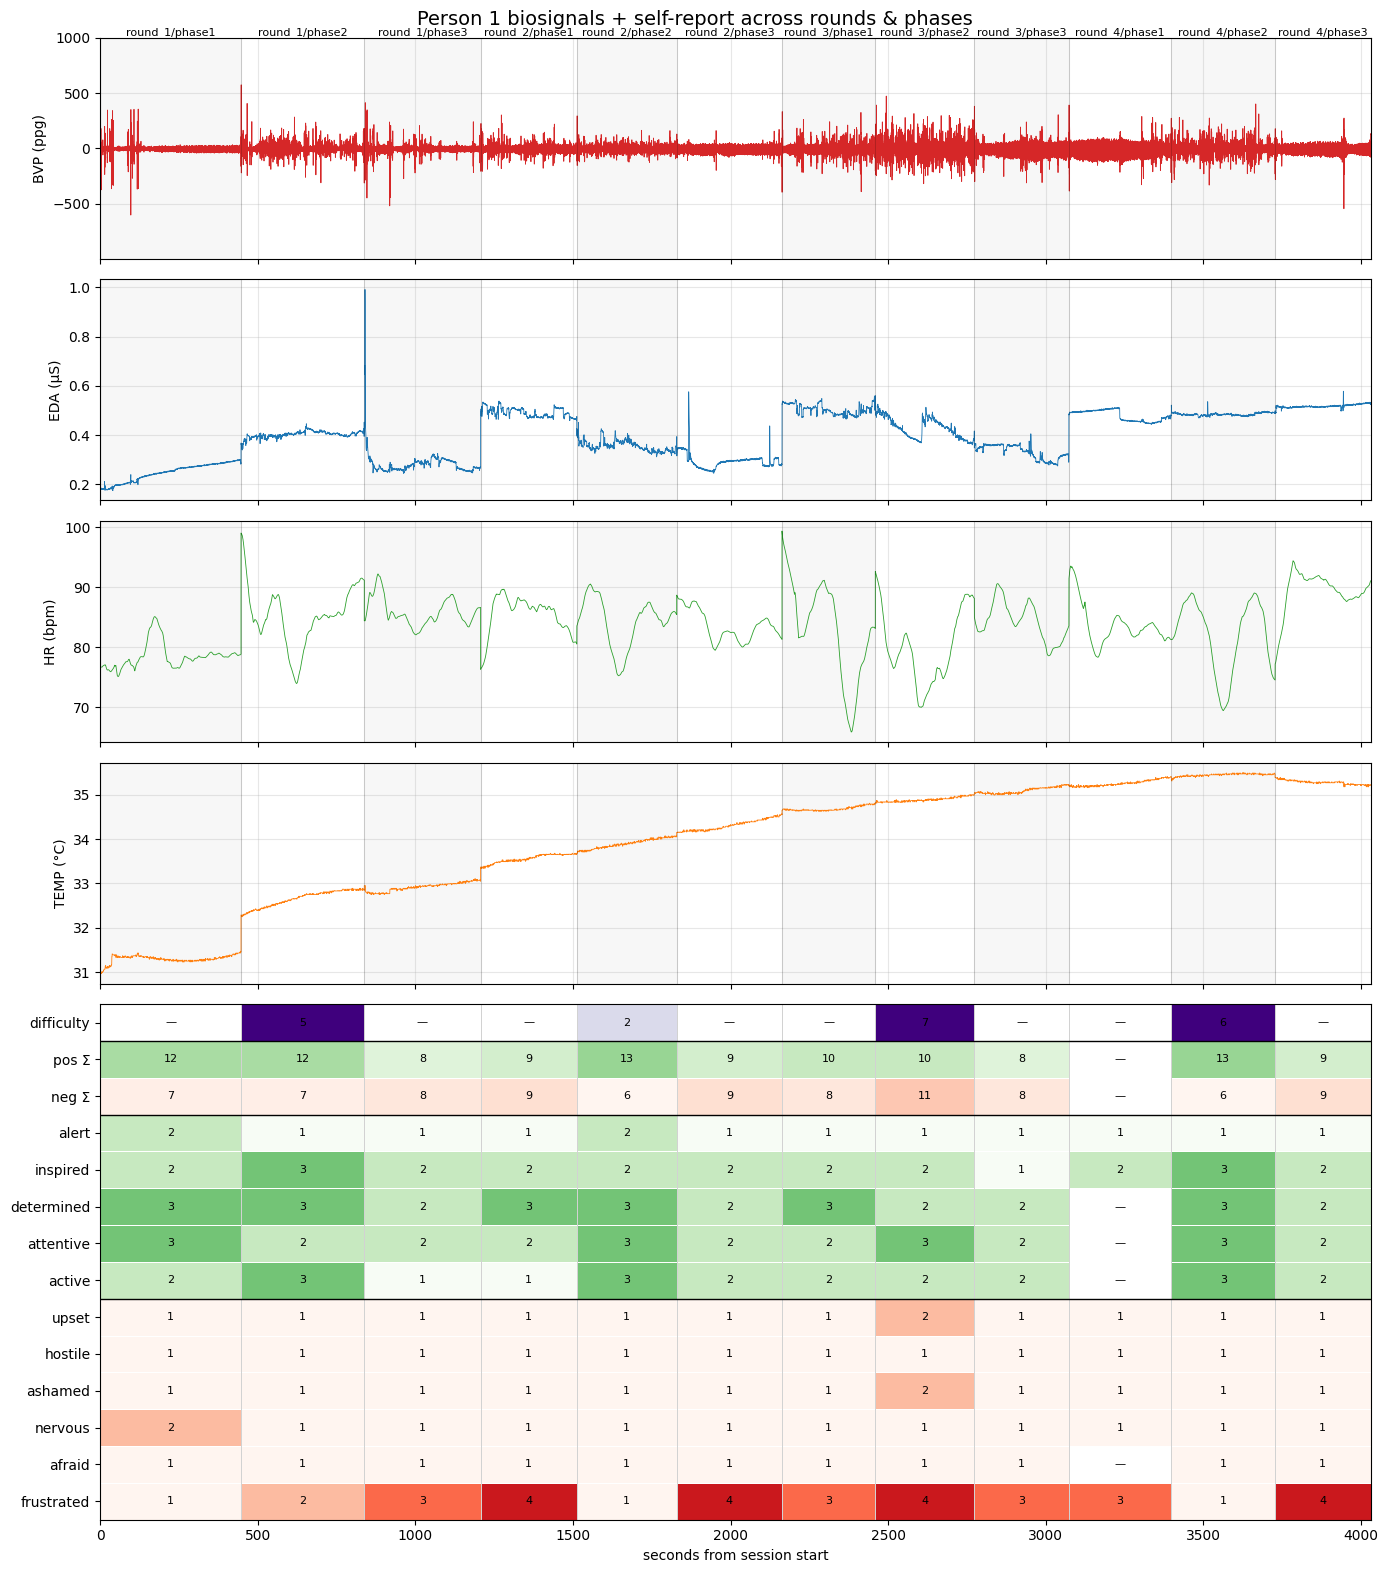

In [ ]:
# parse the time column as DateTime for correct plotting
p1_biosigs_df["time"] = pd.to_datetime(p1_biosigs_df["time"])

# the `time` column resets at the start of each (round, phase). build a continuous
# x-axis by computing seconds-from-start within each phase, then offsetting each
# phase by the cumulative duration of all preceding phases.
df = p1_biosigs_df.copy()
df["phase_key"] = df["round"] + "/" + df["phase"]
phase_order = df["phase_key"].drop_duplicates().tolist()

elapsed_parts = []
phase_bounds = {}  # phase_key -> (start_sec, end_sec)
running_offset = 0.0
for key in phase_order:
    chunk = df.loc[df["phase_key"] == key, "time"]
    secs = (chunk - chunk.iloc[0]).dt.total_seconds()
    start = running_offset
    end = running_offset + secs.iloc[-1]
    phase_bounds[key] = (start, end)
    elapsed_parts.append(secs + running_offset)
    running_offset = end

df["t"] = pd.concat(elapsed_parts).sort_index()

PANAS_POS = ["alert", "inspired", "determined", "attentive", "active"]
PANAS_NEG = ["upset", "hostile", "ashamed", "nervous", "afraid", "frustrated"]

resp = p1_respons_df.copy()
resp["phase_key"] = resp["round"] + "/" + resp["phase"]
resp["PA"] = resp[PANAS_POS].sum(axis=1, min_count=len(PANAS_POS))
resp["NA"] = resp[PANAS_NEG].sum(axis=1, min_count=len(PANAS_NEG))
resp = resp.set_index("phase_key")

SIGNALS = [
    ("BVP",  "BVP (ppg)", "tab:red"),
    ("EDA",  "EDA (µS)",  "tab:blue"),
    ("HR",   "HR (bpm)",  "tab:green"),
    ("TEMP", "TEMP (°C)", "tab:orange"),
]

ROWS = [
    ("difficulty", "difficulty",  "Purples",    1,  5),
    ("PA",         "pos Σ", "Greens",  5, 25), # the sum of all the positive emotions 
    ("NA",         "neg Σ", "Reds", 6, 30), # the sum of all the negative emotions
    ("alert",      "alert",       "Greens",  1,  5),
    ("inspired",   "inspired",    "Greens",  1,  5),
    ("determined", "determined",  "Greens",  1,  5),
    ("attentive",  "attentive",   "Greens",  1,  5),
    ("active",     "active",      "Greens",  1,  5),
    ("upset",      "upset",       "Reds", 1,  5),
    ("hostile",    "hostile",     "Reds", 1,  5),
    ("ashamed",    "ashamed",     "Reds", 1,  5),
    ("nervous",    "nervous",     "Reds", 1,  5),
    ("afraid",     "afraid",      "Reds", 1,  5),
    ("frustrated", "frustrated",  "Reds", 1,  5),
]

fig, axes = plt.subplots(
    len(SIGNALS) + 1, 1,
    sharex=True,
    figsize=(14, 16),
    gridspec_kw={"height_ratios": [3, 3, 3, 3, 7]},
)
fig.suptitle("Person 1 biosignals + self-report across rounds & phases", fontsize=14)

# biosignal panels
sig_axes = axes[:4]
for ax, (col, label, color) in zip(sig_axes, SIGNALS):
    ax.plot(df["t"], df[col], color=color, linewidth=0.6)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

# alternating phase shading and boundary lines on the signal panels
for i, key in enumerate(phase_order):
    start, end = phase_bounds[key]
    if i % 2 == 0:
        for ax in sig_axes:
            ax.axvspan(start, end, color="grey", alpha=0.06, zorder=0)
    for ax in sig_axes:
        ax.axvline(start, color="black", alpha=0.25, linewidth=0.5)

# phase labels above the top panel
top = sig_axes[0]
for key in phase_order:
    start, end = phase_bounds[key]
    top.text(
        (start + end) / 2, top.get_ylim()[1], key,
        ha="center", va="bottom", fontsize=8,
    )

# response panel
heat_ax = axes[-1]
edges_x = [phase_bounds[k][0] for k in phase_order] + [phase_bounds[phase_order[-1]][1]]

for row_idx, (col, label, cmap, vmin, vmax) in enumerate(ROWS):
    values = np.array([[resp[col].get(k, np.nan) for k in phase_order]], dtype=float)
    heat_ax.pcolormesh(
        edges_x,
        [row_idx, row_idx + 1],
        values,
        cmap=cmap, vmin=vmin, vmax=vmax,
        shading="flat",
        edgecolors="white", linewidth=0.5,
    )
    for j, key in enumerate(phase_order):
        v = values[0, j]
        cx = (edges_x[j] + edges_x[j + 1]) / 2
        cy = row_idx + 0.5
        text = "—" if np.isnan(v) else (f"{int(v)}" if float(v).is_integer() else f"{v:.1f}")
        heat_ax.text(cx, cy, text, ha="center", va="center", fontsize=8, color="black")

group_breaks = [1, 3, 8]
for y in group_breaks:
    heat_ax.axhline(y, color="black", linewidth=1.0)

heat_ax.set_yticks([i + 0.5 for i in range(len(ROWS))])
heat_ax.set_yticklabels([r[1] for r in ROWS])
heat_ax.set_ylim(len(ROWS), 0)  # row 0 (difficulty) on top
heat_ax.set_xlabel("seconds from session start")

for key in phase_order:
    heat_ax.axvline(phase_bounds[key][0], color="black", alpha=0.25, linewidth=0.5)

plt.tight_layout()
plt.savefig("person_1_biosignals.png")
plt.savefig("person_1_biosignals.svg")
plt.show()